## Лаборатоная работа №2
#### Ковалев Андрей ИУ5-63Б
### Загрузка библиотек

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
%matplotlib inline 
sns.set(style="ticks")

### Загрузка и первичный анализ данных
#### Используются два датасета:
#### 1. Датасет отзывов с портала "Rotten tomatoes"

In [43]:
reviews = pd.read_csv('rotten_tomatoes_critic_reviews.csv', sep=",")
print('Кол-во строк: ', reviews.shape[0],'\n' ,'Кол-во столбцов: ', reviews.shape[1], sep = '')
print(reviews.dtypes)
print('Пропуски по столбцам:', reviews.isnull().sum())
reviews.head(8)

Кол-во строк: 1130017
Кол-во столбцов: 8
rotten_tomatoes_link    object
critic_name             object
top_critic                bool
publisher_name          object
review_type             object
review_score            object
review_date             object
review_content          object
dtype: object
Пропуски по столбцам: rotten_tomatoes_link         0
critic_name              18529
top_critic                   0
publisher_name               0
review_type                  0
review_score            305936
review_date                  0
review_content           65806
dtype: int64


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...
5,m/0814255,David Germain,True,Associated Press,Rotten,NaN,2010-02-10,It's more a list of ingredients than a movie-m...
6,m/0814255,Nick Schager,False,Slant Magazine,Rotten,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...
7,m/0814255,Bill Goodykoontz,True,Arizona Republic,Fresh,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ..."


#### 2. Датасет данных о фильмах портала "Rotten tomatoes"

In [44]:
movies = pd.read_csv('rotten_tomatoes_movies.csv', sep=",")
print('Кол-во строк: ', movies.shape[0],'\n' ,'Кол-во столбцов: ', movies.shape[1], sep = '')
print(movies.dtypes)
movies.head(4)

Кол-во строк: 17712
Кол-во столбцов: 22
rotten_tomatoes_link                 object
movie_title                          object
movie_info                           object
critics_consensus                    object
content_rating                       object
genres                               object
directors                            object
authors                              object
actors                               object
original_release_date                object
streaming_release_date               object
runtime                             float64
production_company                   object
tomatometer_status                   object
tomatometer_rating                  float64
tomatometer_count                   float64
audience_status                      object
audience_rating                     float64
audience_count                      float64
tomatometer_top_critics_count         int64
tomatometer_fresh_critics_count       int64
tomatometer_rotten_critics_count    

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0


### Обработка пропусков в данных
#### Производилась только для первого датасета

In [45]:
# Исключим из датасета строки с одновременно пустыми полями 'review_score' и 'review_content'.
reviews_1 = reviews.copy()
reviews_1.dropna(axis=0, how='all', subset = ['review_score', 'review_content'])
print('Было: ', reviews.shape[0],'\n','Стало: ',reviews_1.shape[0], sep = '')
# Заменим пропуски в колонках critic_name и review_content на 'Noname' и 'No content'
reviews_1.fillna({'critic_name':'Noname', 'review_content':'No content'}, inplace = True)

# Напишем функцию, переводящую значение столбца "review_score" во float

def score2float(score) -> float:
    if(isinstance(score, float)): return score
    if '/' in score:
        part2 = float(score[score.index('/')+1:])
        if part2 == 0: return None
        return float(score[:score.index('/')])/part2
    else:
        marks = {'A':1.0,'B':0.8,'C':0.6,'D':0.4,'F':0.2 }
        for key in marks:
            if key in score:
                if '-' in score: return marks[key]-0.1
                else: return marks[key]

# Преобразуем стобец "review_score"

reviews_1["review_score"] = reviews_1["review_score"].apply(score2float)
reviews_1["review_score"].astype(float)
print(reviews_1["review_score"].info())

# Заменим пропуски в review_score на среднее значение для соотвествующей категории (Rotten или Fresh)

imputer = SimpleImputer(strategy = 'mean')
indicator = MissingIndicator()
reviews_segments = [reviews_1[reviews_1['review_type'] == 'Rotten'],reviews_1[reviews_1['review_type'] == 'Fresh']]
for i in range(len(reviews_segments)):
    score_col = reviews_segments[i][['review_score']].copy()
    mask_missing= indicator.fit_transform(score_col)
    score_col = imputer.fit_transform(score_col)
    filled_reviews = score_col[mask_missing]
    print(filled_reviews[filled_reviews.size-1])
    reviews_segments[i]['review_score'] = score_col
reviews_1 = pd.concat(reviews_segments)
print('Пропуски по столбцам:', reviews_1.isnull().sum())

Было: 1130017
Стало: 1130017
<class 'pandas.core.series.Series'>
RangeIndex: 1130017 entries, 0 to 1130016
Series name: review_score
Non-Null Count   Dtype  
--------------   -----  
822481 non-null  float64
dtypes: float64(1)
memory usage: 8.6 MB
None
0.42750230498832537
0.7670672713914108


C:\Users\Dru09\AppData\Local\Temp\ipykernel_21008\782407647.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_segments[i]['review_score'] = score_col
C:\Users\Dru09\AppData\Local\Temp\ipykernel_21008\782407647.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_segments[i]['review_score'] = score_col


Пропуски по столбцам: rotten_tomatoes_link    0
critic_name             0
top_critic              0
publisher_name          0
review_type             0
review_score            0
review_date             0
review_content          0
dtype: int64


### Преобразование категориальных признаков в числовые
#### Производилась только для первого датасета

In [46]:

#Заменим publisher_name числовыми значениями
cat_enc = pd.DataFrame({'c1':reviews_1['publisher_name']})
print(cat_enc['c1'].unique())
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])
print(np.unique(cat_enc_le))
count_arr = []
for i in range(0, len(cat_enc['c1'].unique())):
    count_arr = count_arr + [i]
print(le.inverse_transform(count_arr))

reviews_1['publisher_name'] = cat_enc_le
reviews_1.head(10)

['Hollywood Reporter' 'Associated Press' 'Slant Magazine' ...
 'Portland Press-Herald' 'The F Word UK' 'The GWW']
[   0    1    2 ... 2227 2228 2229]
['(All (Parentheses))' '1428 Elm' '1More Film Blog' ... 'www.kcactive.com'
 'www.susangranger.com' 'ÜberCiné']


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
4,m/0814255,Ethan Alter,True,853,Rotten,0.427502,2010-02-10,What's really lacking in The Lightning Thief i...
5,m/0814255,David Germain,True,95,Rotten,0.427502,2010-02-10,It's more a list of ingredients than a movie-m...
6,m/0814255,Nick Schager,False,1639,Rotten,0.250000,2010-02-10,Harry Potter knockoffs don't come more transpa...
11,m/0814255,Roger Moore,True,1341,Rotten,0.500000,2010-02-10,"For what it is and for whom it is intended, it..."
12,m/0814255,David Jenkins,True,1982,Rotten,0.400000,2010-02-10,Chris Columbus returns to his comfort zone for...
14,m/0814255,Peter Paras,False,539,Rotten,0.600000,2010-02-11,This cast is simply too generic. None of the y...
17,m/0814255,Mark Dujsik,False,1092,Rotten,0.625000,2010-02-11,"Admirably, the movie isn't bogged down in the ..."
19,m/0814255,Mary Elizabeth Williams,True,1534,Rotten,0.427502,2010-02-11,"When the movie slows down to catch its breath,..."
21,m/0814255,Stephen Holden,True,1271,Rotten,0.400000,2010-02-11,Although the standard allegorical bases for my...
22,m/0814255,Jeffrey M. Anderson,False,397,Rotten,0.250000,2010-02-11,A little bit worse than lifeless; it's clueles...


### Масштабирование данных
#### Производилась только для второго датасета

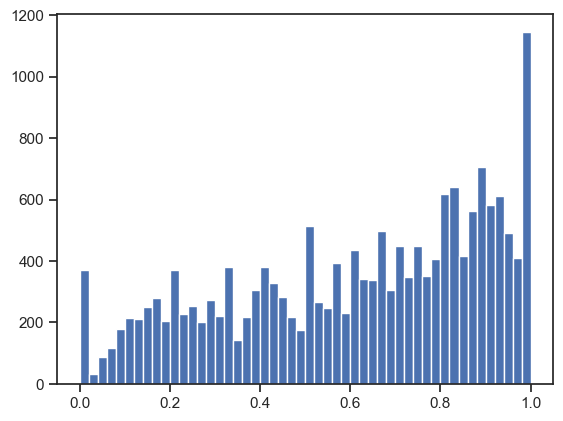

In [47]:
#Отмасштабируем рейтинг фильма
sc = MinMaxScaler()
sc_reviews = sc.fit_transform(movies[['tomatometer_rating']])
plt.hist(sc_reviews, 50, range=[0, 1])
plt.show()